# Hafta 6: WaveNet

Başlangıç: hafta 4 BatchNorm'lu MLP.

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
%matplotlib inline

In [ ]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/karpathy/makemore/master/names.txt", "names.txt")

('names.txt', <http.client.HTTPMessage at 0x7e7d8ae6b930>)

In [ ]:
words = open('names.txt' , 'r').read().splitlines()
len(words)

32033

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

## Veri

In [ ]:
block_size = 8 # context

In [ ]:
# build the dataset

def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [ ]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


## Model (BatchNorm'lu MLP)

In [ ]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn ((fan_in,fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self,x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])
#_______________________________________________________________________________
class BatchNorm1d:
  def __init__(self,dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__ (self,x):
    if self.training:
      if x.ndim==2:
        dim = 0
      elif x.ndim ==3:
        dim = (0,1)

      xmean = x.mean(dim,keepdim=True)
      xvar = x.var(dim,keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
## updating___
    if self.training:
      with torch.no_grad():
        self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
 #__________
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]
#_______________________________________________________________________________
class Tanh:
  def __call__(self,x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []
#_______________________________________________________________________________
class Embedding:
  def __init__ (self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__ (self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]
#_______________________________________________________________________________

class FlattenConsecutive:
  def __init__ (self,n):
    self.n = n

  def __call__ (self,x):
    B, T, C = x.shape
    x = x.view(B, T // self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

#_______________________________________________________________________________

class Sequential:

  def __init__ (self,layers):
    self.layers = layers

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters (self):
    return [p for layer in self.layers for p in layer.parameters()]



In [ ]:
torch.manual_seed(42);

In [ ]:
n_embd = 24
n_hidden= 128

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden,vocab_size),
])
with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
   p.requires_grad = True

76579


In [ ]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0, 12, 15],
        [ 0,  0,  0,  0, 16, 15, 18, 20],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 12,  1, 25,  1, 14, 14]])

In [ ]:
for layer in model.layers:
  print (layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [ ]:
# Embedding (4,8,10) 4 örnek 8 karakter context için ve her karakterin 10 boyutlu vektörü
# FC (4,4,20) 4 örnek 8 karakteri 2 li olarak birleştirince 4 tane oldu. 2x10 = 20
# Linear (4,4,20) linear işleme soktuk. (20,200) weight ile girdi.
# BatchNorm1d (4,4,200) shape değişmedi. sayılar değişti sadece.
# Tanh (4,4,200)'e elementwise tanh uygulandı. shape değişmedi. sayılar değişti sadece.
# 2. FC (4,2,400) oldu. (4 / 2) , (200 * 2)
# Linear (4,2,200) çünkü (400,200) olacak şekilde matrix çarpım oldu.
# BatchNorm1d (4,2,200) shape aynı sadece sayılar değişti.
# Tanh (4,2,200) shape aynı sadece sayılar değişti.
# 3. FC (4,400) artık bir boyut squeeze edildi 1 kaldığı için (2/2=1), (200*2=400)
# Linear (4,200) çünkü (400,200) bir matrix çarpımına girdi.
# BatchNorm1d (4,200) shape aynı sadece sayılar değişti.
# Tanh (4,200) shape aynı sadece sayılar değişti.
# Linear : (4, 27) çünkü (4,200) @ (200,27) oldu.


In [ ]:
for layer in model.layers:
  print (layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [ ]:
model.layers[0].out.shape

torch.Size([4, 8, 10])

In [ ]:
model.layers[1].out.shape

torch.Size([4, 80])

In [ ]:
model.layers[2].out.shape

torch.Size([4, 200])

In [ ]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,),)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) #loss

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # lr decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2820
  10000/ 200000: 1.8245
  20000/ 200000: 1.7262
  30000/ 200000: 1.9193
  40000/ 200000: 1.5643
  50000/ 200000: 2.0025
  60000/ 200000: 2.1791
  70000/ 200000: 2.3886
  80000/ 200000: 1.6235
  90000/ 200000: 2.0526
 100000/ 200000: 1.7356
 110000/ 200000: 1.8065
 120000/ 200000: 1.9295
 130000/ 200000: 1.6213
 140000/ 200000: 1.7316
 150000/ 200000: 2.1298
 160000/ 200000: 1.5226
 170000/ 200000: 1.5994
 180000/ 200000: 2.0014
 190000/ 200000: 1.6319


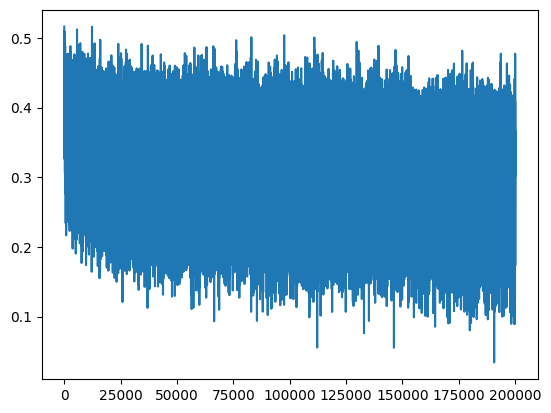

In [ ]:
plt.plot(lossi)

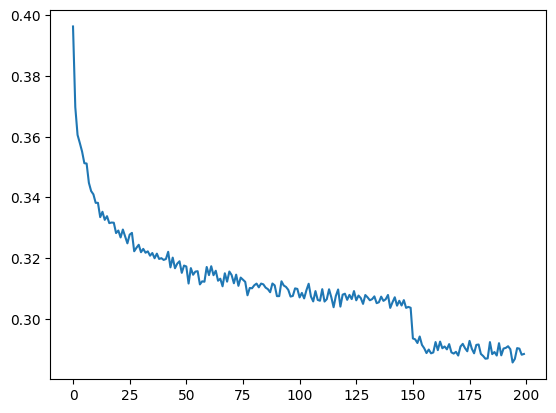

In [ ]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [ ]:
for layer in model.layers:
  layer.training = False

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7675821781158447
val 1.9854739904403687


8 karakter context ile
dev loss : 2.034247875213623

parametre sayısı
12.097 → 22.097, 10.000 arttı.
ilk Linear artık 30 değil 80 sayı alıyor


val 2.022491693496704 Hatalı Batchnorm Dev Loss Değeri

düzeltilmis batchnorm ve daha fazla parametre ile dev loss :  1.9893252849578857

| Model | Parametre sayısı | Dev loss |
|---|---|---|
| Bağlam 3, MLP | 12.097 | 2.1065 |
| Bağlam 8, düz MLP | 22.097 | 2.0342 |
| Bağlam 8, WaveNet (n_embd 24, n_hidden 128) | 76.579 | 1.9855 |

In [ ]:
model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

In [ ]:
e = torch.randn(32, 4 , 68)
emean = e.mean(0, keepdim=True) # 1 , 4 , 68
evar = e.var(0,keepdim=True) # 1 , 4, 68
ehat = (e-emean) / torch.sqrt(evar + 1e-5) # 32 , 4 , 68
ehat.shape

torch.Size([32, 4, 68])

In [ ]:
e = torch.randn(32, 4 , 68)
emean = e.mean((0,1), keepdim=True) # 1 , 1 , 68
evar = e.var((0,1),keepdim=True) # 1 , 1, 68
ehat = (e-emean) / torch.sqrt(evar + 1e-5) # 32 , 4 , 68
emean.shape

torch.Size([1, 1, 68])

In [ ]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

## Örnek isim üretme

In [ ]:
for layer in model.layers:
    layer.training = False

# sample from the MLP model
for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

mority.
nikoleah.
samade.
stefanie.
makya.
mark.
loriara.
zian.
nazary.
yuvin.
roslynn.
raelyn.
rhia.
amore.
talub.
rajvin.
jaxsaiah.
mattiz.
sarim.
ozella.
